# Exotic Fruit Classification

TropicTaste Inc., a leader in the distribution of exotic fruits, aims to improve efficiency and accuracy in the fruit classification process. The goal is to develop a machine learning model capable of predicting the type of fruit based on numerical features.

The current exotic fruit classification process is manual and prone to errors, making it inefficient and resource-intensive. The need for an automated and accurate system is crucial to optimize business operations and maintain high quality standards.

By implementing an automated classification model, TropicTaste Inc. will be able to:

- Improve Operational Efficiency: Automating the classification process will reduce the time and resources required, increasing productivity.
- Reduce Human Errors: A machine learning model will minimize classification errors, ensuring greater accuracy.
- Optimize Inventory: Accurate classification will enable better inventory management, ensuring optimal storage conditions for each type of fruit.
- Increase Customer Satisfaction: Correct identification and classification of fruits will help maintain high quality standards, improving customer satisfaction.

## Project Details:

- Dataset: Use of a dataset containing various numerical features of different exotic fruits.
- Algorithm: Implementation of the K-Nearest Neighbors (KNN) algorithm for classification.
- Output: The model must correctly predict the type of fruit based on the provided data.
  Project Requirements:

## Dataset Preparation:

- Loading and preprocessing of the exotic fruit data.
- Handling of any missing values, normalization, and scaling of the data.

## KNN Model Implementation:

- Development and training of the KNN model.
- Optimization of parameters to improve predictive accuracy.

## Performance Evaluation:

- Use of cross-validation techniques to evaluate the model's generalization ability.
- Calculation of performance metrics, such as accuracy and classification error.

## Results Visualization:

- Creation of charts to visualize and compare model performance.
- Analysis and interpretation of the results to identify potential areas for improvement.

## Dataset Variables

The dataset can be downloaded here: https://proai-datasets.s3.eu-west-3.amazonaws.com/fruits.csv

It contains the following variables:

- Fruit: The type of fruit. This is the target variable that we want to predict.
- Weight (g): The weight of the fruit in grams. Continuous variable.
- Average Diameter (mm): The average diameter of the fruit in millimeters. Continuous variable.
- Average Length (mm): The average length of the fruit in millimeters. Continuous variable.
- Peel Hardness (1-10): The hardness of the fruit's peel on a scale from 1 to 10. Continuous variable.
- Sweetness (1-10): The sweetness of the fruit on a scale from 1 to 10. Continuous variable.

Remember to perform a proper exploratory analysis of the dataset before proceeding with the model. Also remember to apply the correct preprocessing to the data and measure the model's performance according to the metrics you consider most useful.

Accompany each step of the analysis with appropriate charts and provide adequate commentary for each step, extracting useful insights for the analysis and understanding of the information conveyed by the data.


## 1 - Dataset Preparation:

- Loading and preprocessing the exotic fruit data.
- Handling any missing values, normalization, and scaling of the data.

In [ ]:
# Initial setup and import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, log_loss

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline

In [ ]:
# Random seed for reproducibility
RANDOM_SEED = 0

In [ ]:
# File loading and check to avoid unwanted new creations.
import os
if not os.path.isfile('fruits.csv'):
  !wget https://proai-datasets.s3.eu-west-3.amazonaws.com/fruits.csv

In [ ]:
# Dataset opening
df = pd.read_csv('fruits.csv')
df.head()

,Frutto,Peso (g),Diametro medio (mm),Lunghezza media (mm),Durezza buccia (1-10),Dolcezza (1-10)
0,Mela,86.40,89.68,8.69,9.61,2.41
1,Mela,77.58,73.45,6.49,7.20,3.87
2,Mela,81.95,81.66,6.40,9.09,2.88
3,Mela,66.33,36.71,6.78,8.21,2.55
4,Mela,56.73,75.69,5.78,9.15,3.88


In [ ]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Frutto                 500 non-null    object 
 1   Peso (g)               500 non-null    float64
 2   Diametro medio (mm)    500 non-null    float64
 3   Lunghezza media (mm)   500 non-null    float64
 4   Durezza buccia (1-10)  500 non-null    float64
 5   Dolcezza (1-10)        500 non-null    float64
dtypes: float64(5), object(1)
memory usage: 23.6+ KB


In [ ]:
# Descriptive statistics
df.describe()

,Peso (g),Diametro medio (mm),Lunghezza media (mm),Durezza buccia (1-10),Dolcezza (1-10)
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,47.313440,86.573100,5.298620,7.437640,3.593220
std,26.768797,64.293403,2.641993,1.812548,1.264899
min,8.570000,7.530000,1.150000,3.070000,1.250000
25%,24.797500,50.510000,2.672500,6.152500,2.570000
50%,42.380000,70.450000,5.670000,7.340000,3.535000
75%,68.080000,88.852500,7.455000,8.615000,4.465000
max,111.210000,299.890000,11.140000,13.720000,6.950000


In [ ]:
# Check null values
df.isna().sum()

,0
Frutto,0
Peso (g),0
Diametro medio (mm),0
Lunghezza media (mm),0
Durezza buccia (1-10),0
Dolcezza (1-10),0


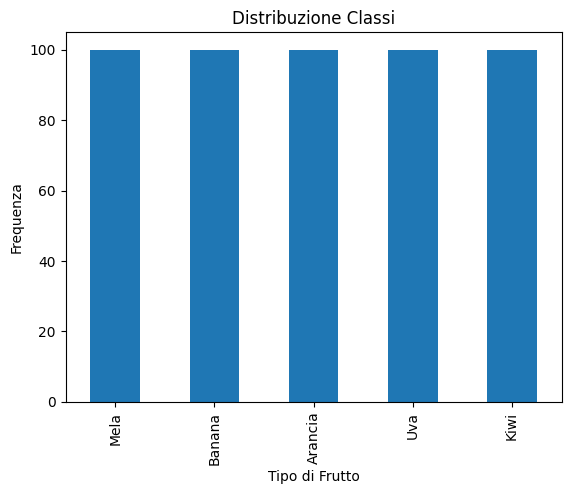

In [ ]:
# Class (Target) distribution
df['Frutto'].value_counts().plot(kind='bar')
plt.title("Class distribution")
plt.xlabel("Fruit type")
plt.ylabel("Frequenza")
plt.show()

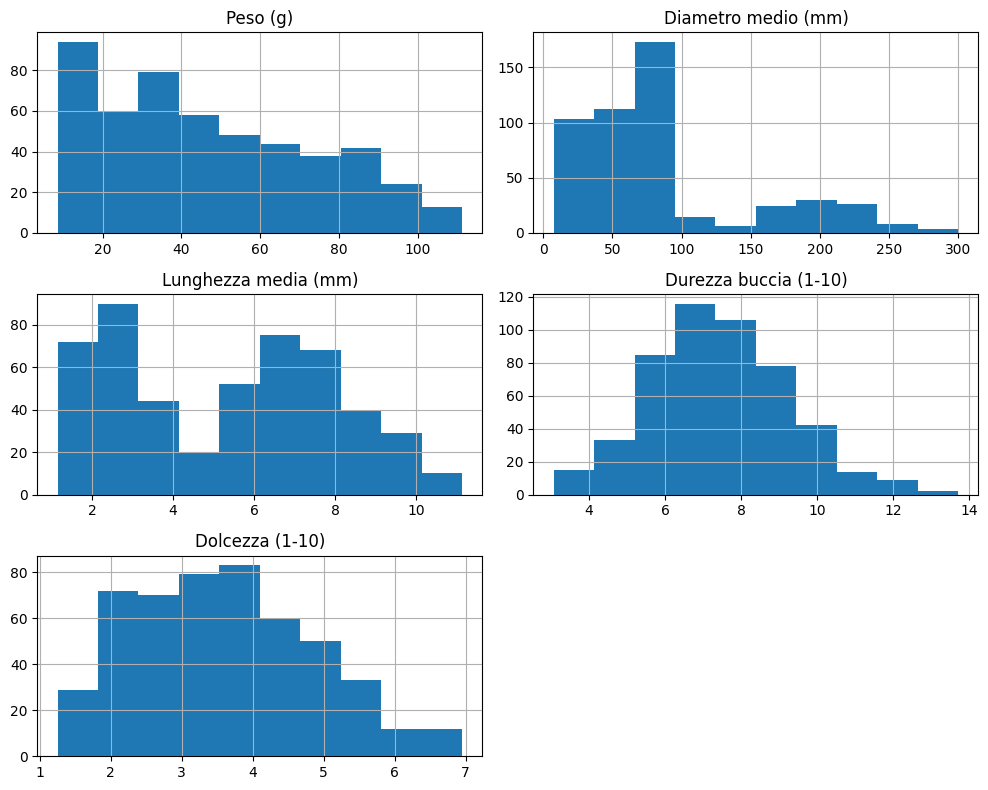

In [ ]:
# Feature distribution
df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

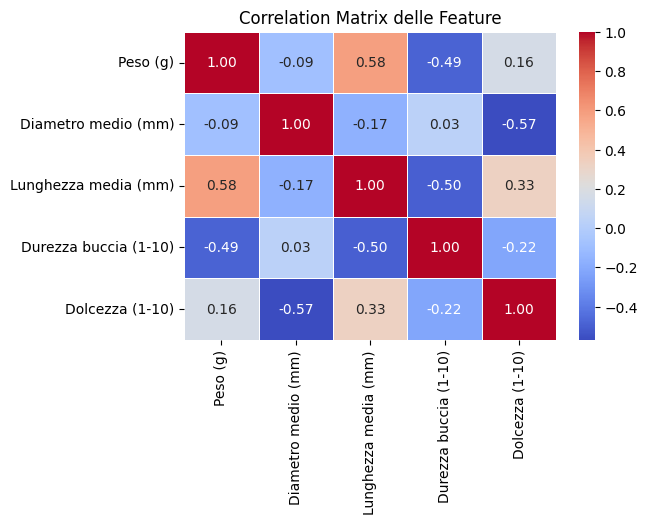

In [ ]:
# Correlation matrix delle sole feature
plt.figure(figsize=(6,4))
corr_matrix = df.drop("Frutto", axis=1).corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.show()


### Preliminary considerations on the dataset:

The absence of null values, the uniform distribution of the target classes (= balanced dataset), and the overall cleanliness of the dataset mean that no specific actions are necessary in this regard.

The distribution of the features, on the other hand, highlights the need to scale the data (particularly because we expect to use a KNN model).

Finally, the correlation matrix highlights some correlations that are not problematic but are nevertheless moderate (around 50%) between weight, peel hardness, and diameter.

In [ ]:
# Delete target column.
# Features
X = df.drop("Frutto", axis=1).values
# Target
y = df["Frutto"].values
# Check before proceeding
X.shape, y.shape

((500, 5), (500,))

In [ ]:
# Train and test array creation with 70/30 distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.3, random_state=RANDOM_SEED
)
# Check before proceeding
X_train.shape, X_test.shape

((350, 5), (150, 5))

In [ ]:
# Standardization - to normalize and bring values to a common scale - as emerged from the preliminary analysis,
# is included in the following section ("2 - KNN Model Implementation"), as it is directly incorporated into the pipeline used by GridSearchCV.

## 2 - KNN Model Implementation:
- Development and training of the KNN model.
- Parameter optimization to improve predictive accuracy.

The **choice of parameters** was made according to the criterion of evaluating multiple options to find the best results:

- **n_neighbours** = initially set to 25 (starting from the common practice of taking the square root of the number of training samples and leaving a small additional margin), it was then increased to 31 to leave a larger margin compared to the best k found (also following a best practice in this case).
- **weights** = initially I used both 'uniform' and 'distance', but this choice led GridSearchCV to select 'distance', which created a situation of slight overfitting (train was perfect but test dropped to 0.920) without achieving better test performance than 'uniform' (indicating a reduction in bias but a slight increase in variance), so I chose to use only 'uniform' for greater stability.
- **metric** = in this case I chose to evaluate multiple possibilities, allowing GridSearchCV to find which was the best choice, without forcing a decision a priori.

In [ ]:
# Model creation

# k range
ks = range(1, 31)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': list(ks),
    'knn__weights': ['uniform'],
    'knn__metric': ['euclidean', 'manhattan']
}

# Use of GridSearchCV() to find best parameters for the model
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

#grid.best_params_, grid.best_score_
print(f"Best Parameters: {grid.best_params_}")
print(f"Best Accuracy: {grid.best_score_:.3f}")

Migliori Parametri: {'knn__metric': 'manhattan', 'knn__n_neighbors': 29, 'knn__weights': 'uniform'}
Migliore Accuracy: 0.934


## 3 - Performance Evaluation:
- Use of cross-validation techniques to evaluate the model's generalization ability.
- Calculation of performance metrics, such as accuracy and classification error.

In [ ]:
# Use of cross validation techniques to evaluate the generalization's ability of the best model
best_model = grid.best_estimator_

#Cross-validation (fit already implicit in the method used)
# NOTE: in this case cv=10 compared to the 5 folds used in GridSearchCV.
# The difference is due to the desire to follow the best practice of:
# - trying to save computational resources during the exploration phase (GridSearchCV),
# - being slightly more precise afterwards, when there is only one already-selected model to work with.
cv_results = cross_val_score(best_model, X_train, y_train, cv=10)

# Cross validation stability
print(f"Model's average stability: {cv_results.mean():.3f} (with standard deviation of: {cv_results.std() * 2:.3f})")

# Train
y_pred_train = best_model.predict(X_train)
y_proba_train = best_model.predict_proba(X_train)
# Test
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)

print(f"Train -> Accuracy: {accuracy_score(y_train, y_pred_train):.3f} | Log Loss: {log_loss(y_train, y_proba_train):.3f} | Confusion error: {1 - accuracy_score(y_train, y_pred_train):.3f}")
print(f"Test -> Accuracy: {accuracy_score(y_test, y_pred_test):.3f} | Log Loss: {log_loss(y_test, y_proba_test):.3f} | Confusion error: {1 - accuracy_score(y_test, y_pred_test):.3f}\n")

Stabilità media del modello: 0.934 (con deviazione standard di: 0.063)
Train -> Accuracy: 0.943 | Log Loss: 0.207 | Confusion error: 0.057
Test -> Accuracy: 0.933 | Log Loss: 0.212 | Confusion error: 0.067



In [ ]:
# Train
print(classification_report(y_train, y_pred_train))


              precision    recall  f1-score   support

     Arancia       0.89      0.84      0.87        69
      Banana       1.00      1.00      1.00        73
        Kiwi       0.88      0.88      0.88        68
        Mela       0.93      0.99      0.96        71
         Uva       1.00      1.00      1.00        69

    accuracy                           0.94       350
   macro avg       0.94      0.94      0.94       350
weighted avg       0.94      0.94      0.94       350



In [ ]:
# Test
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

     Arancia       0.88      0.90      0.89        31
      Banana       1.00      1.00      1.00        27
        Kiwi       0.86      0.97      0.91        32
        Mela       0.96      0.79      0.87        29
         Uva       1.00      1.00      1.00        31

    accuracy                           0.93       150
   macro avg       0.94      0.93      0.93       150
weighted avg       0.94      0.93      0.93       150



## 4 - Results Visualization:
- Creation of charts to visualize and compare the model's performance.
- Analysis and interpretation of the results to identify potential areas for improvement.

In [ ]:
# Function to show confusion matrix
def show_confusion_matrix(y_phase, y_pred_phase, title_phase):
  cm = confusion_matrix(y_phase, y_pred_phase)
  plt.figure(figsize=(6, 4))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=best_model.classes_,
              yticklabels=best_model.classes_)
  plt.xlabel('Predetto')
  plt.ylabel('Reale')
  plt.title('Matrice di Confusione: '+ title_phase)
  plt.show()

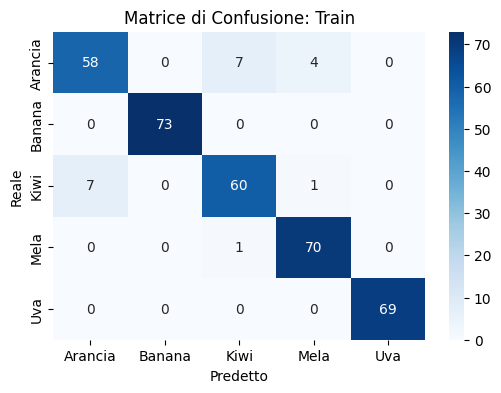

In [ ]:
# Train confusion matrix
show_confusion_matrix(y_train, y_pred_train, "Train")

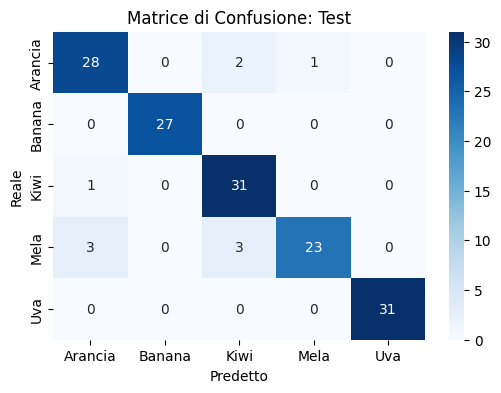

In [ ]:
# Test confusion matrix
show_confusion_matrix(y_test, y_pred_test, "Test")

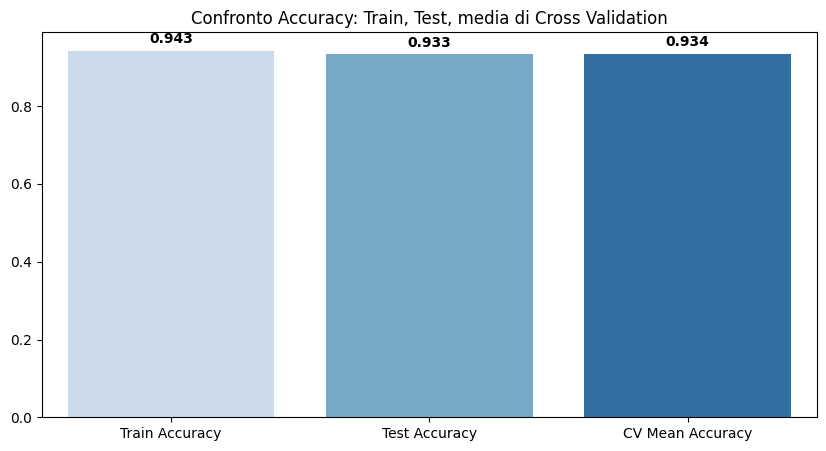

In [ ]:
# Comparison of train and test accuracy
labels = ['Train Accuracy', 'Test Accuracy', 'CV Mean Accuracy']
values = [accuracy_score(y_train, y_pred_train),
          accuracy_score(y_test, y_pred_test),
          cv_results.mean()]

plt.figure(figsize=(10, 5))
sns.barplot(x=labels, y=values, palette='Blues', hue=labels)
plt.title('Comparison Accuracy: Train, Test, avg of Cross Validation')
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()

### Final Analysis:

The numerical results obtained from the accuracy, log loss, and confusion error outputs show that the training results are very good and that the gap with the test results is also very small, indicating that the model performs well without any concerning signs of overfitting.

The visualization, in addition to confirming what was already shown by the numerical results, also clearly highlights that during training the model confuses oranges, kiwis, and apples with each other much more frequently than other fruits, while bananas and grapes are easier to predict; the same trend can also be observed during testing.

This aspect, which suggests that some features of these classes have similar values, may suggest trying to increase the distribution of these features further during the dataset preparation phase.

Nevertheless, the last histogram (Accuracy Comparison: Train, Test, Cross-Validation Mean) shows a high average accuracy emerging from the various folds during cross-validation (CV Mean Accuracy), with a particularly high value (0.934), indicating that the model is stable.

In conclusion, we have a good model with excellent results, although it is probably possible to achieve further improvements when distinguishing between oranges, kiwis, and apples.
